# 01 — Exploratory Data Analysis (EDA)
**BBC News Classification Project**

In this notebook we explore the dataset before any modelling:
- Dataset shape and balance
- Text length distribution
- Most frequent words per category
- Word cloud per category


In [3]:
import os, pandas as pd

rows = []
base = "D:\\Term2\\bbc-news-classifier_full\\bbc-news-classifier\\data\\bbc"   # ← غيّر ده للمسار الصح عندك

for category in os.listdir(base):
    cat_path = os.path.join(base, category)
    if os.path.isdir(cat_path):
        for fname in os.listdir(cat_path):
            fpath = os.path.join(cat_path, fname)
            with open(fpath, 'r', encoding='latin-1') as f:
                rows.append({'category': category, 'text': f.read()})

df = pd.DataFrame(rows)
df.to_csv('D:\\Term2\\bbc-news-classifier_full\\bbc-news-classifier\\data\\bbc-text.csv', index=False)
print(df['category'].value_counts())

category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


In [4]:
import os, sys
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

# reproducibility
np.random.seed(42)
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11

## 1. Load Data

In [5]:
df = pd.read_csv('../data/bbc-text.csv')
print(f"Shape : {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Shape : (2225, 2)
Columns: ['category', 'text']


,category,text
0,business,Ad sales boost Time Warner profit\n\nQuarterly...
1,business,Dollar gains on Greenspan speech\n\nThe dollar...
2,business,Yukos unit buyer faces loan claim\n\nThe owner...


In [6]:
print("Null values:")
print(df.isnull().sum())
print()
print("Category distribution:")
print(df['category'].value_counts())

Null values:
category    0
text        0
dtype: int64

Category distribution:
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


## 2. Class Balance

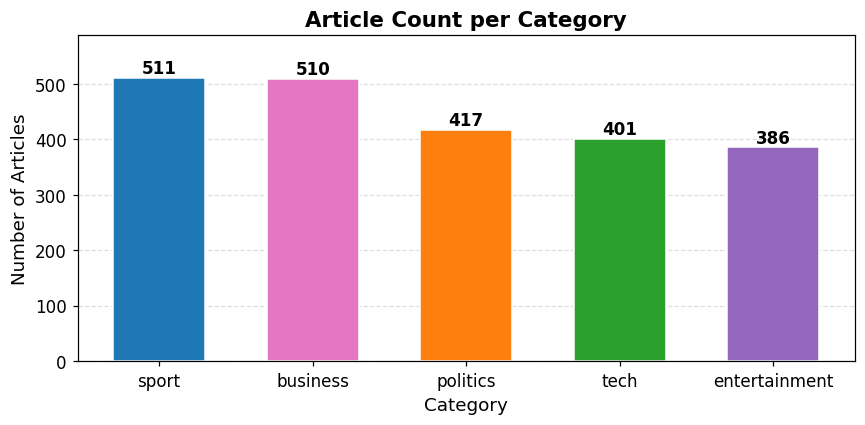


Most common : sport (511)
Least common: entertainment (386)
Imbalance ratio: 1.32x


In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
counts = df['category'].value_counts()
colors = ['#1f77b4','#e377c2','#ff7f0e','#2ca02c','#9467bd']
bars = ax.bar(counts.index, counts.values, color=colors, width=0.6, edgecolor='white')

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            str(val), ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Number of Articles', fontsize=12)
ax.set_title('Article Count per Category', fontsize=14, fontweight='bold')
ax.set_ylim(0, counts.max() * 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
print(f"\nMost common : {counts.idxmax()} ({counts.max()})")
print(f"Least common: {counts.idxmin()} ({counts.min()})")
print(f"Imbalance ratio: {counts.max()/counts.min():.2f}x")

## 3. Text Length Distribution

In [8]:
df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print("Word count statistics:")
print(df.groupby('category')['word_count'].describe().round(1))

Word count statistics:
               count   mean    std    min    25%    50%    75%     max
category                                                              
business       510.0  328.9  135.9  140.0  233.0  297.0  388.8   891.0
entertainment  386.0  330.6  261.8  143.0  225.0  262.5  360.0  3482.0
politics       417.0  454.0  300.1   89.0  317.0  439.0  529.0  4432.0
sport          511.0  329.3  188.0  114.0  204.0  288.0  409.5  1662.0
tech           401.0  502.7  239.8  162.0  338.0  447.0  629.0  2969.0


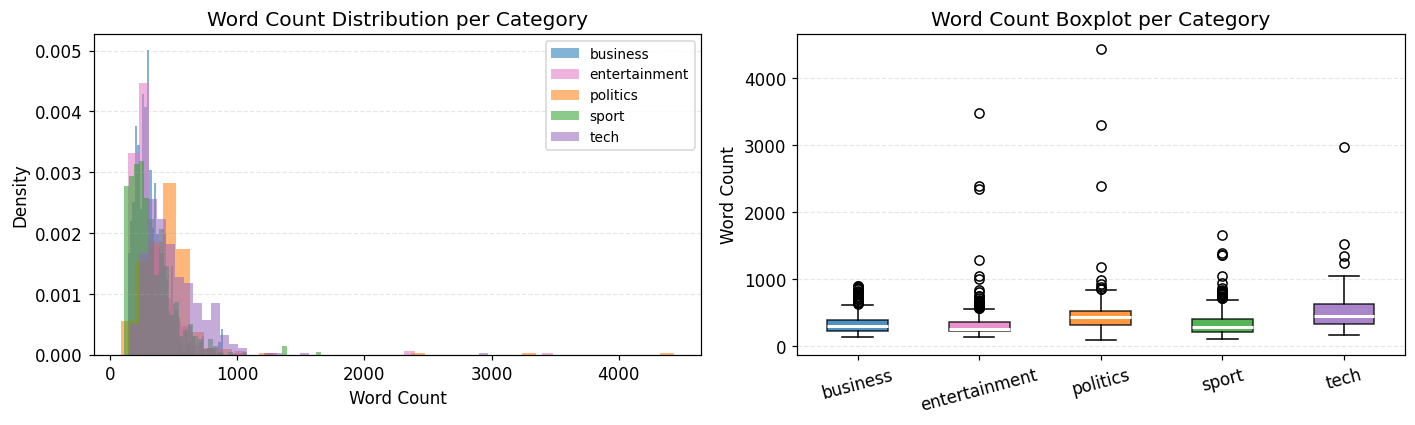

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
categories = df['category'].unique()
cat_colors = dict(zip(sorted(categories), colors))

# Word count distribution
for cat in sorted(categories):
    subset = df[df['category'] == cat]['word_count']
    axes[0].hist(subset, bins=40, alpha=0.55, label=cat,
                 color=cat_colors[cat], density=True)
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Density')
axes[0].set_title('Word Count Distribution per Category')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

# Boxplot
data_by_cat = [df[df['category']==c]['word_count'].values for c in sorted(categories)]
bp = axes[1].boxplot(data_by_cat, patch_artist=True, notch=False,
                     medianprops=dict(color='white', linewidth=2))
for patch, cat in zip(bp['boxes'], sorted(categories)):
    patch.set_facecolor(cat_colors[cat])
    patch.set_alpha(0.8)
axes[1].set_xticklabels(sorted(categories), rotation=15)
axes[1].set_ylabel('Word Count')
axes[1].set_title('Word Count Boxplot per Category')
axes[1].grid(axis='y', linestyle='--', alpha=0.3)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

## 4. Most Frequent Words per Category (after preprocessing)

In [10]:
from src.preprocessor import TextPreprocessor
preprocessor = TextPreprocessor(remove_stopwords=True)

word_freq = {}
for cat in sorted(categories):
    texts = df[df['category'] == cat]['text'].tolist()
    all_tokens = []
    for t in texts:
        all_tokens.extend(preprocessor.process(t))
    word_freq[cat] = Counter(all_tokens)

print("Top 10 words per category:")
for cat, freq in word_freq.items():
    top = freq.most_common(10)
    print(f"  {cat:15s}: {[w for w,_ in top]}")

Top 10 words per category:
  business       : ['mr', 'bn', 'market', 'growth', 'company', 'last', 'economy', 'firm', 'sales', 'bank']
  entertainment  : ['film', 'best', 'music', 'years', 'show', 'awards', 'last', 'first', 'award', 'number']
  politics       : ['mr', 'government', 'labour', 'people', 'election', 'blair', 'party', 'minister', 'told', 'brown']
  sport          : ['game', 'against', 'first', 'win', 'england', 'last', 'world', 'back', 'players', 'play']
  tech           : ['people', 'mr', 'technology', 'mobile', 'games', 'users', 'other', 'music', 'use', 'digital']


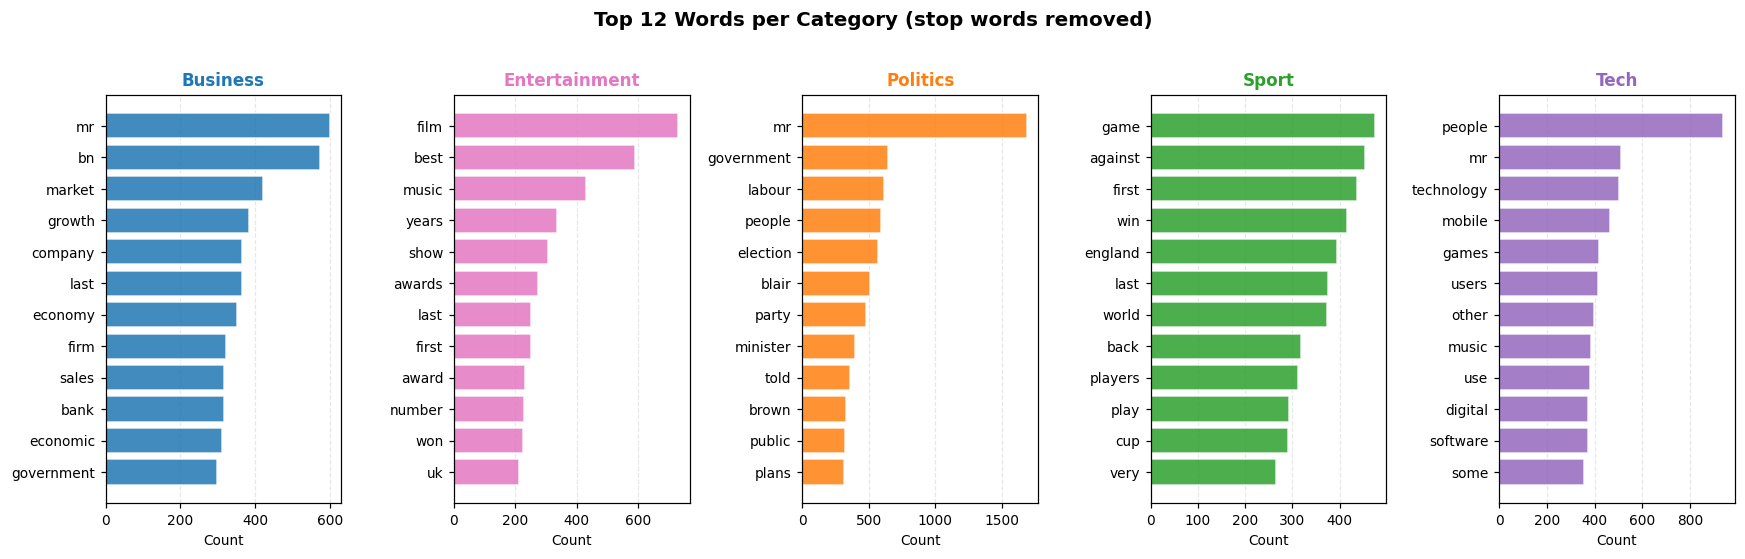

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(16, 5))
for ax, cat in zip(axes, sorted(categories)):
    top_words = word_freq[cat].most_common(12)
    words  = [w for w, _ in top_words][::-1]
    counts = [c for _, c in top_words][::-1]
    color  = cat_colors[cat]
    ax.barh(words, counts, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(cat.capitalize(), fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Count', fontsize=9)
    ax.tick_params(labelsize=9)
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)

fig.suptitle('Top 12 Words per Category (stop words removed)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Vocabulary Overlap Between Categories

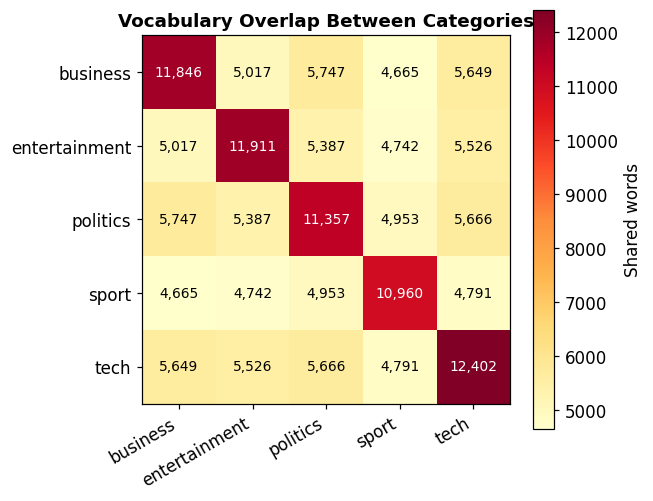


Note: high overlap = harder to separate. Low overlap = easier for Naive Bayes.


In [12]:
# How many words are shared between categories?
vocab_per_cat = {cat: set(word_freq[cat].keys()) for cat in sorted(categories)}
cats = sorted(categories)
n = len(cats)
overlap_matrix = np.zeros((n, n), dtype=int)

for i, c1 in enumerate(cats):
    for j, c2 in enumerate(cats):
        overlap_matrix[i, j] = len(vocab_per_cat[c1] & vocab_per_cat[c2])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(overlap_matrix, cmap='YlOrRd')
fig.colorbar(im, ax=ax, label='Shared words')
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(cats, rotation=30, ha='right')
ax.set_yticklabels(cats)
ax.set_title('Vocabulary Overlap Between Categories', fontsize=12, fontweight='bold')
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{overlap_matrix[i,j]:,}', ha='center', va='center',
                fontsize=9, color='black' if overlap_matrix[i,j] < overlap_matrix.max()*0.7 else 'white')
plt.tight_layout()
plt.show()
print("\nNote: high overlap = harder to separate. Low overlap = easier for Naive Bayes.")

## Summary

| Finding | Insight |
|---|---|
| Dataset is **nearly balanced** | No need for resampling |
| **Sport** articles are shortest | More direct language |
| **Politics** articles are longest | More verbose |
| **Tech & Business** share vocabulary | May cause some confusion |
| **Sport** has unique vocabulary | Should be easiest to classify |

→ Next step: `02_experiments.ipynb` — train and evaluate the model.
